# Discounted Cash Flow (DCF) Model

A discounted cash flow model estimates what a business is worth today based on the cash it can generate in the future.

Abbreviations used in this notebook:

- **DCF**: Discounted Cash Flow, a valuation method based on present values of future cash flows.
- **FCF**: Free Cash Flow, cash generated by the business after capital expenditures.
- **PV**: Present Value, today's value of a future cash flow.
- **TV**: Terminal Value, the estimated value of cash flows after the explicit forecast period.
- **EV**: Enterprise Value, the value of the operating business before subtracting net debt.
- **WACC**: Weighted Average Cost of Capital, the blended required return used as a discount rate.
- **GDP**: Gross Domestic Product, the broad value of goods and services produced in an economy.
- **CHF**: Swiss franc, the currency used in the examples.

## 1. Intuition

DCF answers one central question:

> What is this company worth based on the future cash it can generate for owners?

The model has three moving parts:

- **Explicit forecast period**: cash flows we forecast year by year.
- **Discount rate**: the required return for bearing the company risk, often WACC.
- **Terminal value**: the value of cash flows after the explicit forecast period.

DCF is powerful because it connects valuation to business fundamentals. It is also fragile because small changes in growth, margins, WACC, or terminal growth can create large valuation changes.

## 2. Mathematics

**Projected free cash flow:**

$$
FCF_t = FCF_0 \times (1 + g)^t
$$

Where:

- $FCF_t$ = free cash flow in period $t$
- $FCF_0$ = starting free cash flow
- $g$ = long-term growth rate
- $t$ = time period index

**Present value of explicit cash flows:**

$$
PV_{FCF} = \sum_{t=1}^{N} \frac{FCF_t}{(1+r)^t}
$$

Where:

- $FCF_t$ = free cash flow in period $t$
- $PV_{FCF}$ = present value of explicit free cash flows
- $r$ = discount rate or required return
- $t$ = time period index

**Terminal value using the Gordon Growth formula:**

$
TV = \frac{FCF_N \times (1 + g_{terminal})}{r - g_{terminal}}
$

Where:

- $FCF_N$ = free cash flow in the final explicit forecast year
- $r$ = discount rate or required return
- $TV$ = terminal value at the end of the explicit forecast period
- $g_{terminal}$ = perpetual terminal growth rate

The terminal value estimates all cash flows after the explicit forecast period. If the forecast ends in year $N$, the formula first grows $FCF_N$ by one more year using $g_{terminal}$, then capitalizes that growing cash-flow stream using $r - g_{terminal}$. The terminal value is not today's value yet; it must still be discounted back to today.

The discount rate $r$ should match the cash flow being valued. For free cash flow to the firm, $r$ is usually WACC because the cash flows belong to both debt and equity providers. WACC is driven by the cost of equity, after-tax cost of debt, capital structure, tax rate, and company risk.

The terminal growth rate $g_{terminal}$ should represent sustainable long-term growth after the company has matured. It is usually anchored to long-term inflation, real GDP growth, industry maturity, and the currency of the cash flows. For a mature company in a developed market, terminal growth is often modest and should usually stay below long-term nominal GDP growth.

The formula requires $r > g_{terminal}$. If $g_{terminal}$ is close to $r$, the denominator becomes very small and the terminal value becomes unrealistically large and highly sensitive.

**Enterprise value:**

$$
EV = PV_{FCF} + \frac{TV}{(1+r)^N}
$$

Where:

- $PV_{FCF}$ = present value of explicit free cash flows
- $r$ = discount rate or required return
- $TV$ = terminal value
- $EV$ = enterprise value, the value of the operating business

**Equity value:**

$$
\text{Equity Value} = EV - \text{Net Debt}
$$

Where:

- $EV$ = enterprise value, the value of the operating business
- $\text{Equity Value}$ = value attributable to shareholders
- $\text{Net Debt}$ = debt minus cash and cash equivalents

**Intrinsic value per share:**

$$
\text{Value per Share} = \frac{\text{Equity Value}}{\text{Shares Outstanding}}
$$

Where:

- $\text{Equity Value}$ = value attributable to shareholders
- $\text{Value per Share}$ = intrinsic equity value per share
- $\text{Shares Outstanding}$ = number of shares issued and outstanding

## 3. Implementation

We will build a reusable DCF model with a Nestle-like example. The numbers are synthetic and expressed in CHF millions, but the workflow mirrors a real valuation model.

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")


def project_fcf(fcf0, growth, years):
    """Project free cash flow at a constant annual growth rate."""
    return np.array([fcf0 * (1 + growth) ** t for t in range(1, years + 1)])


def terminal_value(fcf_last, terminal_growth, discount_rate):
    if discount_rate <= terminal_growth:
        raise ValueError("Discount rate must be greater than terminal growth.")
    return fcf_last * (1 + terminal_growth) / (discount_rate - terminal_growth)


def dcf_model(fcf0, forecast_growth, discount_rate, terminal_growth, years, net_debt=0, shares_outstanding=1):
    fcfs = project_fcf(fcf0, forecast_growth, years)
    discount_factors = np.array([(1 + discount_rate) ** t for t in range(1, years + 1)])
    pv_fcfs = fcfs / discount_factors

    tv = terminal_value(fcfs[-1], terminal_growth, discount_rate)
    pv_terminal_value = tv / ((1 + discount_rate) ** years)
    enterprise_value = pv_fcfs.sum() + pv_terminal_value
    equity_value = enterprise_value - net_debt
    value_per_share = equity_value / shares_outstanding

    forecast = pd.DataFrame({
        "year": np.arange(1, years + 1),
        "fcf": fcfs,
        "discount_factor": discount_factors,
        "pv_fcf": pv_fcfs,
    })

    summary = {
        "pv_explicit_fcfs": pv_fcfs.sum(),
        "terminal_value": tv,
        "pv_terminal_value": pv_terminal_value,
        "enterprise_value": enterprise_value,
        "net_debt": net_debt,
        "equity_value": equity_value,
        "value_per_share": value_per_share,
        "terminal_value_share_of_ev": pv_terminal_value / enterprise_value,
    }

    return forecast, summary

## 4. Visualization

First we run a base case, then visualize the explicit cash flows and the sensitivity of valuation to assumptions.

In [42]:
assumptions = {
    "fcf0": 10_000,
    "forecast_growth": 0.04,
    "discount_rate": 0.06,
    "terminal_growth": 0.02,
    "years": 5,
    "net_debt": 35_000,
    "shares_outstanding": 2_650,
}

forecast, summary = dcf_model(**assumptions)

forecast

,year,fcf,discount_factor,pv_fcf
0,1,10400.000000,1.060000,9811.320755
1,2,10816.000000,1.123600,9626.201495
2,3,11248.640000,1.191016,9444.575052
3,4,11698.585600,1.262477,9266.375523
4,5,12166.529024,1.338226,9091.538249


In [43]:
summary_table = pd.Series(summary).to_frame("value")
summary_table.loc[[
    "pv_explicit_fcfs",
    "pv_terminal_value",
    "enterprise_value",
    "net_debt",
    "equity_value",
    "value_per_share",
    "terminal_value_share_of_ev",
]]

,value
pv_explicit_fcfs,47240.011073
pv_terminal_value,231834.225339
enterprise_value,279074.236412
net_debt,35000.000000
equity_value,244074.236412
value_per_share,92.103485
terminal_value_share_of_ev,0.830726


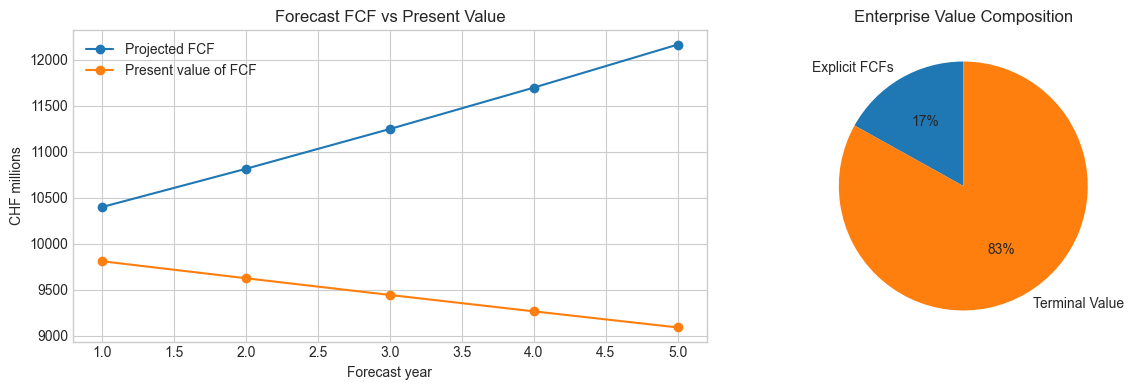

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

forecast.plot(x="year", y=["fcf", "pv_fcf"], marker="o", ax=axes[0])
axes[0].set_title("Forecast FCF vs Present Value")
axes[0].set_xlabel("Forecast year")
axes[0].set_ylabel("CHF millions")
axes[0].legend(["Projected FCF", "Present value of FCF"])

value_split = pd.Series({
    "Explicit FCFs": summary["pv_explicit_fcfs"],
    "Terminal Value": summary["pv_terminal_value"],
})
axes[1].pie(value_split, labels=value_split.index, autopct="%1.0f%%", startangle=90)
axes[1].set_title("Enterprise Value Composition")

plt.tight_layout()
plt.show()

In [45]:
wacc_values = np.linspace(0.045, 0.08, 8)
forecast_growth_values = np.linspace(0.01, 0.06, 8)

sensitivity = pd.DataFrame(index=wacc_values, columns=forecast_growth_values, dtype=float)

for wacc in wacc_values:
    for growth in forecast_growth_values:
        _, case_summary = dcf_model(
            fcf0=assumptions["fcf0"],
            forecast_growth=growth,
            discount_rate=wacc,
            terminal_growth=assumptions["terminal_growth"],
            years=assumptions["years"],
            net_debt=assumptions["net_debt"],
            shares_outstanding=assumptions["shares_outstanding"],
        )
        sensitivity.loc[wacc, growth] = case_summary["value_per_share"]

sensitivity.round(2)

,0.010000,0.017143,0.024286,0.031429,0.038571,0.045714,0.052857,0.060000
0.045,133.70,138.71,143.86,149.16,154.60,160.19,165.93,171.82
0.050,109.27,113.41,117.66,122.03,126.52,131.14,135.87,140.74
0.055,91.82,95.33,98.95,102.66,106.47,110.39,114.41,118.53
0.060,78.73,81.78,84.91,88.13,91.43,94.83,98.31,101.89
0.065,68.55,71.23,73.99,76.83,79.74,82.73,85.79,88.94
0.070,60.40,62.80,65.26,67.79,70.38,73.05,75.78,78.59
0.075,53.74,55.90,58.11,60.39,62.73,65.13,67.59,70.12
0.080,48.18,50.14,52.16,54.23,56.35,58.53,60.77,63.06


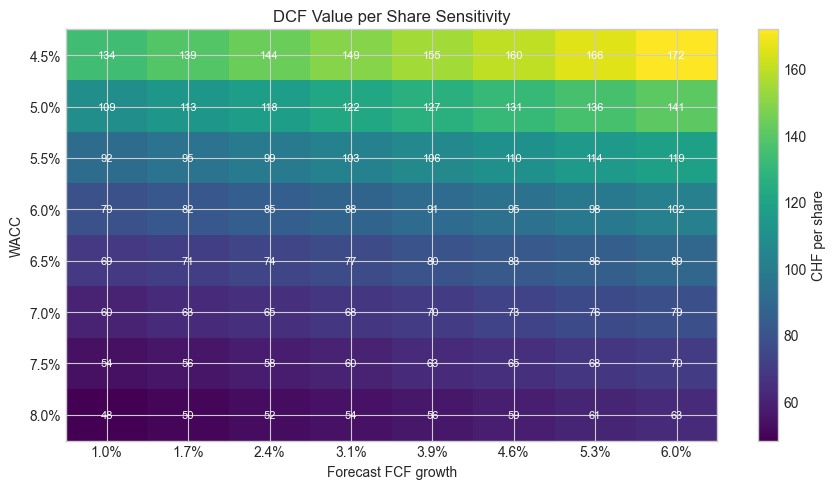

In [46]:
fig, ax = plt.subplots(figsize=(9, 5))
image = ax.imshow(sensitivity.values, aspect="auto", cmap="viridis")

ax.set_xticks(range(len(forecast_growth_values)))
ax.set_xticklabels([f"{g:.1%}" for g in forecast_growth_values])
ax.set_yticks(range(len(wacc_values)))
ax.set_yticklabels([f"{w:.1%}" for w in wacc_values])
ax.set_xlabel("Forecast FCF growth")
ax.set_ylabel("WACC")
ax.set_title("DCF Value per Share Sensitivity")

for row in range(sensitivity.shape[0]):
    for col in range(sensitivity.shape[1]):
        ax.text(col, row, f"{sensitivity.values[row, col]:.0f}", ha="center", va="center", color="white", fontsize=8)

fig.colorbar(image, ax=ax, label="CHF per share")
plt.tight_layout()
plt.show()

## 5. Application

In equity research, a DCF is usually used alongside market multiples and qualitative judgment.

For a mature consumer staples company such as Nestle, the most important checks are:

- Is forecast FCF growth realistic compared with revenue growth and margin history?
- Is WACC consistent with the risk of a defensive global company and the cash flows being discounted?
- Is terminal growth below long-term nominal GDP growth for the relevant currency region?
- Is the gap between WACC and terminal growth large enough to avoid an unstable terminal value?
- Does terminal value dominate the model too heavily?
- Does the implied value per share differ meaningfully from the market price?

A DCF should not produce a single magic number. It should produce a valuation range and reveal which assumptions drive the range. A small change in WACC or terminal growth can move valuation materially, so terminal value assumptions should always be tested with sensitivity tables and scenarios.

In [47]:
base_value = summary["value_per_share"]
low_case = sensitivity.min().min()
high_case = sensitivity.max().max()
terminal_weight = summary["terminal_value_share_of_ev"]

print(f"Base value per share: CHF {base_value:,.2f}")
print(f"Sensitivity range: CHF {low_case:,.2f} to CHF {high_case:,.2f}")
print(f"Terminal value share of enterprise value: {terminal_weight:.1%}")

Base value per share: CHF 92.10
Sensitivity range: CHF 48.18 to CHF 171.82
Terminal value share of enterprise value: 83.1%


## 6. Reflection

- DCF valuation translates business assumptions into present value.
- Terminal value often drives most of the enterprise value, especially for stable companies.
- WACC and terminal growth require discipline because small changes can dominate the result.
- A DCF is most useful when it explains the assumptions required to justify a market price.
- Always compare DCF output against relative valuation, historical performance, and business quality.

Questions to answer after running the notebook:

1. Which assumption moved value per share the most?
2. Is the terminal value share reasonable for this type of company?
3. What evidence would you need before trusting the forecast growth rate?
4. Would you use the base case as an investment decision, or only as one input?